# PQD CNN Classifier. Training, Saving, Loading, Evaluating and TFLite Converting

In [1]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import numpy as np
import scipy as sp


import time
from IPython.display import display
from matplotlib import pyplot as plt
import matplotlib as mpl

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import Sequential
# Conv2D, MaxPooling2D
from tensorflow.keras.layers import Conv1D, MaxPool1D, BatchNormalization, GlobalMaxPooling1D, Flatten, Dense

from keras.utils import plot_model
from keras import regularizers

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split#, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

import seaborn as sns

Dataset signal properties defines for file saving and uploading

In [3]:
# Adjust the following according to dataset
NUM_OF_PQD = 16
NUM_SIGNALS_PER_PQD = 2000
FREQUENCY = 60
NUM_OF_CYCLES = 10
NOISE = True

SAMPLING_RATE = 3200

# Signal period = (1/50) * 10 = 200 ms
# Signal samples = 0.2 / (1/3200) = 640 samples
# Probably not needed
NUM_OF_FEATURES = (NUM_OF_CYCLES / FREQUENCY) * SAMPLING_RATE

BASE_FILENAME = str(NUM_OF_PQD) + 'pqd_' + str(NUM_SIGNALS_PER_PQD) + 'pattern_' + str(FREQUENCY) + 'hz_' + str(NUM_OF_CYCLES) + 'cycle_'

if NOISE:
    BASE_FILENAME += 'withNoise'
else:
    BASE_FILENAME += 'noNoise'

Datasets and models should be generated with a meaningful name, including how many PQD types and how much signals per PQD type are there.

Dataset generator's sampling rate is 3.2 kHz, frequency can be ser to 50 or 60 Hz.
Example dataset's number of cycles is 10 and nominal frequency is 50 Hz.

In [4]:
BASE_FILENAME

'16pqd_2000pattern_60hz_10cycle_withNoise'

## 1) Import Dataset

In [5]:
databaseLength = NUM_OF_PQD * NUM_SIGNALS_PER_PQD

DATASET_FILENAME = BASE_FILENAME + '.mat'

In [6]:
DataBase = loadmat(DATASET_FILENAME)
X = [None]
Y = [None]

for i in range(databaseLength):
    X.append(DataBase ['SignalsDataBase'][0][i]['signals'][0])
    Y.append(DataBase ['SignalsDataBase'][0][i]['labels'][0])

X = np.array(X[1:])
Y = np.array(Y[1:])

print("Total signals loaded:", X.shape[0])
print("Total signals per PQD:", NUM_SIGNALS_PER_PQD)

print("X np array shape is:", X.shape)
print("Y np array shape is:", Y.shape)

X = np.expand_dims(X, axis=-1)
Y = np.reshape(Y, (len(Y), 1))

print("X and Y np array shape after redimension:", X.shape, Y.shape)

Total signals loaded: 32000
Total signals per PQD: 2000
X np array shape is: (32000, 533)
Y np array shape is: (32000,)
X and Y np array shape after redimension: (32000, 533, 1) (32000, 1)


Bibliography creates dataset using 64 bit float variables

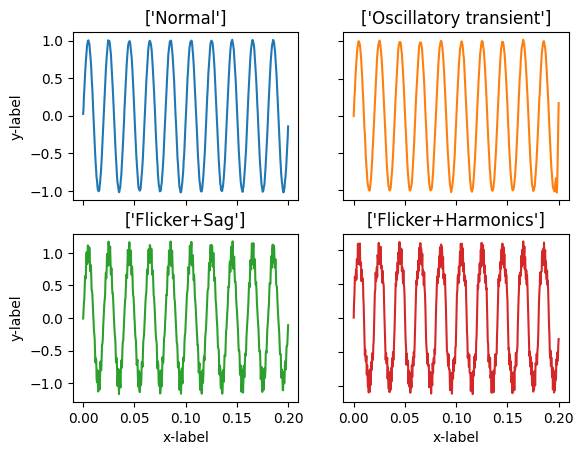

In [7]:
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html
t = np.linspace(0, 0.2, int(NUM_OF_FEATURES))

fig, axs = plt.subplots(2, 2)
axs[0, 0].plot(t, X[10])
axs[0, 0].set_title(Y[10])
axs[0, 1].plot(t, X[11], 'tab:orange')
axs[0, 1].set_title(Y[11])
axs[1, 0].plot(t, X[12], 'tab:green')
axs[1, 0].set_title(Y[12])
axs[1, 1].plot(t, X[13], 'tab:red')
axs[1, 1].set_title(Y[13])

for ax in axs.flat:
    ax.set(xlabel='x-label', ylabel='y-label')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

If the model inference vector is 0, handle_unknown ignores it\
***TODO***: Fix this, either on model output or encoder\
One test returned 0.4 for two elements and argmax extracted the most likely element

In [8]:
# Convert categorical labels into binary format for model output

OHE = OneHotEncoder(handle_unknown='ignore')
Y_OneHot = OHE.fit_transform(Y).toarray()

categories_names = OHE.categories_
print("Class names:", categories_names)
print("Encoded labels example:\n", Y_OneHot[:3])

Class names: [array(['Flicker', 'Flicker+Harmonics', 'Flicker+Sag', 'Flicker+Swell',
       'Harmonics', 'Impulsive Transient', 'Interruption',
       'Interruption+Harmonics', 'Normal', 'Notch',
       'Oscillatory transient', 'Sag', 'Sag+Harmonics', 'Spike', 'Swell',
       'Swell+Harmonics'], dtype='<U22')]
Encoded labels example:
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## 2) Train a Deep CNN

***TODO*** Scheduler function can be implemented using built-in optimizer schedules like ExponentialDecay, epoch-based callbacks like LearningRateScheduler, or performance-based callbacks like ReduceLROnPlateau. (Google search)

In [9]:
def scheduler(epoch):
    """
    Compute the learning rate for the current epoch
    """
    dropEvery = 10
    initAlpha = 0.01
    factor = 0.5
    exp = np.floor((1 + epoch) / dropEvery)
    alpha = initAlpha * (factor ** exp)
    # return the learning rate
    print('lr =', alpha)
    return float(alpha)

In [10]:
base_model = Sequential([
    keras.layers.Input(shape=(640, 1)),
    Conv1D(filters=32, kernel_size=3, strides=1, activation='relu'),
    Conv1D(filters = 32, kernel_size=3, strides = 1, activation='relu'),
    MaxPool1D(pool_size=(3), strides = 1), #TODO : data_format='channels_first' ??
    Conv1D(filters = 64, kernel_size=3,strides = 1, activation='relu'),
    Conv1D(filters = 64, kernel_size=3,strides = 1, activation='relu'),
    MaxPool1D(pool_size=(3), strides = 1),
    Conv1D(filters = 128, kernel_size=3,strides = 1, activation='relu'),
    Conv1D(filters = 128, kernel_size=3,strides = 1, activation='relu'),
    GlobalMaxPooling1D(), #TODO : data_format='channels_first' ??
    BatchNormalization(),
    Flatten(),
    Dense(units=256, activation='relu',use_bias=True),
    Dense(units=128, activation='relu',use_bias=True),
    BatchNormalization(),
    Dense(units=16, activation='softmax',use_bias=True)])

# training parameters:


print (base_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 638, 32)             │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 636, 32)             │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 634, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 632, 64)             │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 630, 64)             │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 628, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 626, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 624, 128)            │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │           2,064 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 164,784 (643.69 KB)

 Trainable params: 164,272 (641.69 KB)

 Non-trainable params: 512 (2.00 KB)

None


In [11]:
# Adjust the following if necessary
TEST_PERCENTAGE = 0.10

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y_OneHot,
    test_size=TEST_PERCENTAGE,
    random_state=42,
    stratify=Y_OneHot
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test:", Y_test.shape)

X_train: (28800, 533, 1)
X_test: (3200, 533, 1)
y_train: (28800, 16)
y_test: (3200, 16)


### Model 1

***TODO*** TFLite model shows additional classes:
ExpandDims and Reshape
Can this be avoided? How to visualize in Keras?

Categorical Cross-Entropy: Use for multi-class predictions with one-hot encoded targets and a softmax output layer.



In [ ]:
opt = keras.optimizers.Nadam()

***TODO*** How much batch_size? Hyperparameter tuning? Does overfitting needs to be avoided?

### Model 2

In [ ]:
# https://keras.io/examples/vision/swin_transformers/
opt = keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.001)

### Model 3

***TODO*** Separate optimizer from three models to avoid redundancy

In [12]:
# https://keras.io/examples/vision/swin_transformers/
opt = keras.optimizers.SGD(learning_rate=0.0001, weight_decay=0.001)

lr = 0.01
Epoch 1/43
450/450 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.7530 - loss: 0.6735 - val_accuracy: 0.3981 - val_loss: 2.0847 - learning_rate: 0.0100
lr = 0.01
Epoch 2/43
450/450 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.8195 - loss: 0.4123 - val_accuracy: 0.4356 - val_loss: 1.9269 - learning_rate: 0.0100
lr = 0.01
Epoch 3/43
450/450 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.8352 - loss: 0.3620 - val_accuracy: 0.6403 - val_loss: 0.8543 - learning_rate: 0.0100
lr = 0.01
Epoch 4/43
450/450 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8388 - loss: 0.3417 - val_accuracy: 0.7063 - val_loss: 0.5956 - learning_rate: 0.0100
lr = 0.01
Epoch 5/43
450/450 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8456 - loss: 0.3224 - val_accuracy: 0.8413 - val_loss: 0.4029 - learning_rate: 0.0100
lr = 0.01
Epoch 6/43
450/450 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.8483 - loss: 0.3157 - val_accuracy: 0.5319 - val_loss: 1.4713 - learning_rate: 0.0100
lr = 0.01
Epoch 

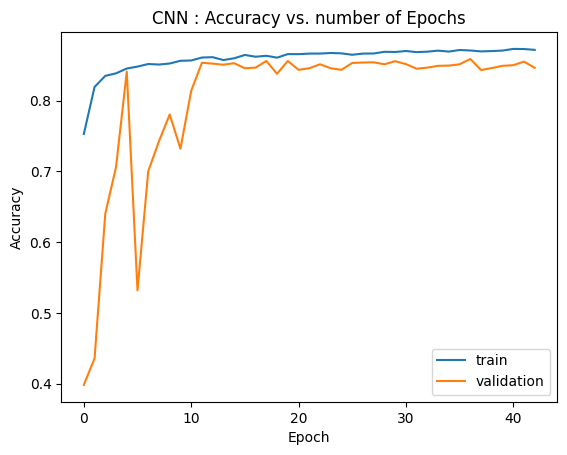

In [13]:
base_model.compile(loss='categorical_crossentropy',
                   optimizer=opt,
                   metrics=['accuracy'])

base_model_history = base_model.fit(X_train, Y_train,
                                    batch_size=64,
                                    epochs=43,
                                    callbacks=[callback],
                                    validation_data=(X_test, Y_test),
                                    verbose=1)

model = base_model

# Plot CNN's accuracy vs. epoch num:
fig = plt.figure()
plt.plot(base_model_history.history['accuracy'])
plt.plot(base_model_history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN : Accuracy vs. number of Epochs')
plt.legend(['train','validation'])
plt.show()

### ***TODO*** Fix visualization, if needed, otherwise, model.summary approach can be used

In [ ]:
!pip install pydot graphviz

In [ ]:
!pip install pydotplus

In [ ]:
from tensorflow.keras import layers, utils

utils.plot_model(
    model, 
    to_file='model_architecture.png', 
    show_shapes=True, 
    show_layer_names=True
)

## 3) File Saving

In [14]:
# Prexis = _MiniBatch_lr
MODEL_FILENAME = BASE_FILENAME + '_SGDOptimised_17'
KERAS_FILENAME = MODEL_FILENAME + '.weights.h5'
JSON_FILENAME = MODEL_FILENAME + '.json'
TFLITE_FILENAME = MODEL_FILENAME + '.tflite'
TFLITE_FLOAT_FILENAME = MODEL_FILENAME + '_floatQuantized.tflite'
TFLITE_QUANT_FILENAME = MODEL_FILENAME + '_intQuantized.tflite'

### Optional. Serialize Model to JSON and Save H5 Model

In [15]:
import json

model_json = base_model.to_json()
with open(JSON_FILENAME, "w") as json_file:
    json_file.write(json.dumps(json.loads(model_json), indent=4))

model.save_weights(KERAS_FILENAME)
print("Saved model to disk")

Saved model to disk


### Optional. Load Model from JSON and Create Model

***TODO*** Unify Pre and Post model variable, user can load or train a model and still run the following code

In [ ]:
json_file = open(JSON_FILENAME, 'r')
loaded_model_json = json_file.read()
json_file.close()

loaded_model = tf.keras.models.model_from_json(loaded_model_json)
# evaluate loaded model on test data
loaded_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy']   )
# load weights into new model:
loaded_model.load_weights(KERAS_FILENAME)
print("Loaded model from disk")

# Define X_test & Y_test data first
model = loaded_model

## Inference Sample

Met the error once, careful with implementation, is round the best approach?

ValueError: Samples [0] can not be inverted when drop=None and handle_unknown='error' because they contain all zeros

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Prediction output is an np.array of size 16: [[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]]

Prediction: Normal , Label: [['Normal']] 
DeepCNN prediction is [ True]


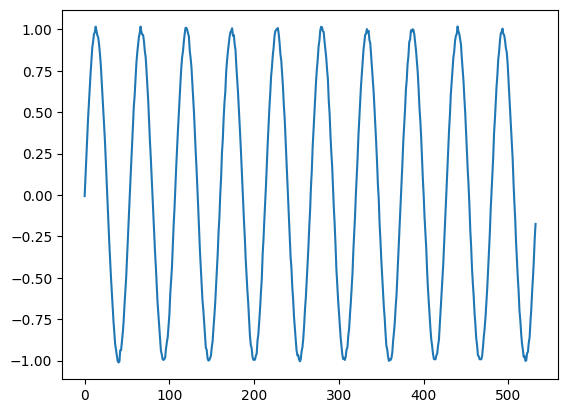

In [16]:
# Given a signal with a disturb 
idx = 3
X_sample = X_test[idx:idx+1]
Y_sample = Y_test[idx:idx+1]

Y_pred = np.round(model.predict(X_sample)).astype('int')
Y_pred_label = OHE.inverse_transform(Y_pred)[0][0]
Y_true_label = OHE.inverse_transform(Y_sample.astype('int'))

print("Prediction output is an np.array of size 16:", Y_pred)

verdict = (Y_pred_label == Y_true_label)
print("\nPrediction:", Y_pred_label, ", Label:" , Y_true_label,"\nDeepCNN prediction is", verdict[0])

plt.plot(X_sample[0])
plt.show()

## Evaluation

In [17]:
score = model.evaluate(X_test, Y_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

compile_metrics: 84.66%


In [18]:
start_test = time.time()

Y_pred = np.round(model.predict(X_test))

end_test = time.time()
testing_time = end_test - start_test
print(f"Testing time: {testing_time:.4f} seconds")

# Not needed, can evaluate float arrays
#Y_pred = Y_pred.astype('int')
#Y_true = Y_test.astype('int')

accuracy = accuracy_score(Y_test, Y_pred)
macro_f1 = f1_score(Y_test, Y_pred, average="macro")
weighted_f1 = f1_score(Y_test, Y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

categories_names = categories_names[0].tolist()

print("\nClassification Report:")
print(classification_report(
    Y_test,
    Y_pred,
    target_names=categories_names
))

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Testing time: 1.4776 seconds
Accuracy: 0.8403
Macro F1-score: 0.8401
Weighted F1-score: 0.8401

Classification Report:
                        precision    recall  f1-score   support

               Flicker       0.94      0.98      0.96       199
     Flicker+Harmonics       1.00      0.99      0.99       200
           Flicker+Sag       1.00      0.98      0.99       201
         Flicker+Swell       1.00      0.96      0.98       198
             Harmonics       0.97      1.00      0.99       200
   Impulsive Transient       1.00      0.95      0.97       202
          Interruption       0.44      0.27      0.34       199
Interruption+Harmonics       0.42      0.36      0.39       201
                Normal       0.86      1.00      0.92       201
                 Notch       0.99      0.96      0.98       200
 Oscillatory transient       0.99      0.97      0.98       199
                   Sag       0.48      0.62      0.54       200
      

C:\Users\nxf93627\.venv-deep-learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


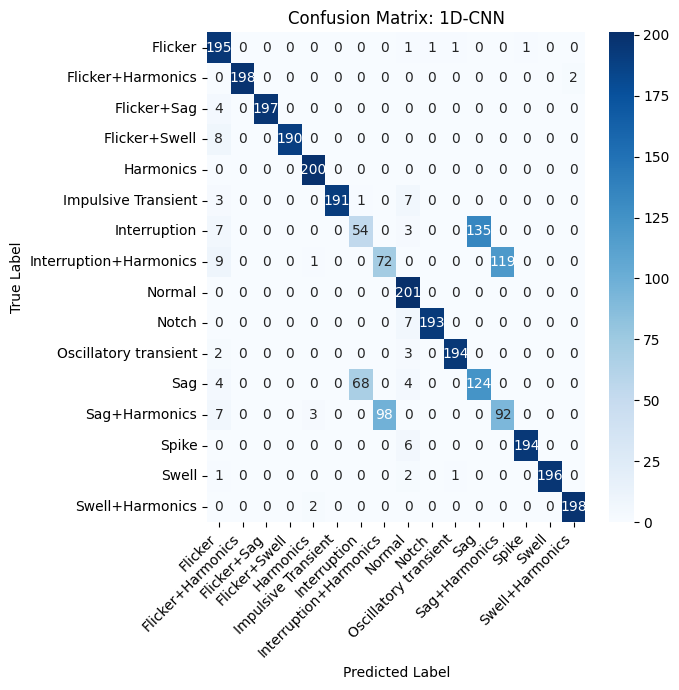

In [19]:
# Confusion function takes one-dimensional data argmax returns the index of the max value
cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))

plt.figure(figsize=(7, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categories_names,
    yticklabels=categories_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: 1D-CNN")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## TFLite Model

In [20]:
import os

def get_file_size(file_path):
    size = os.path.getsize(file_path)
    return size
    
def convert_bytes(size, unit=None):
    if unit == "KB":
        return print('File size: ' + str(round(size / 1024, 3)) + ' Kilobytes')
    elif unit == "MB":
        return print('File size: ' + str(round(size / (1024 * 1024), 3)) + ' Megabytes')
    else:
        return print('File size: ' + str(size) + ' bytes')

Why is there a difference? Previously experiments throwed 2 MB files (they are backed up in other optimizations)

In [21]:
convert_bytes(get_file_size(KERAS_FILENAME), "MB")
keras_model_size = get_file_size(KERAS_FILENAME)

File size: 0.676 Megabytes


### Float conversion

In [22]:
tf_lite_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = tf_lite_converter.convert()

INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmpadl8p2tx\assets


INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmpadl8p2tx\assets


Saved artifact at 'C:\Users\nxf93627\AppData\Local\Temp\tmpadl8p2tx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 640, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  2748333120144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333121296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333118992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333119376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333119952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333119568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333120336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333121680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333122448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2748333122256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  274833

In [23]:
open(TFLITE_FLOAT_FILENAME, "wb").write(tflite_model)

667068

In [24]:
convert_bytes(get_file_size(TFLITE_FLOAT_FILENAME), "KB")
tflite_file_size = get_file_size(TFLITE_FLOAT_FILENAME)

File size: 651.434 Kilobytes


Input shape is overwritten it should be 1

In [31]:
float_interpreter = tf.lite.Interpreter(model_path = TFLITE_FLOAT_FILENAME)
input_details = float_interpreter.get_input_details()
output_details = float_interpreter.get_output_details()
print("Input Shape:", input_details[0]['shape'])
print("Input Signature:", input_details[0]["shape_signature"])
print("Input Type:", input_details[0]['dtype'])
print("Output Shape:", output_details[0]['shape'])
print("Output Type:", output_details[0]['dtype'])

Input Shape: [  1 640   1]
Input Signature: [ -1 640   1]
Input Type: <class 'numpy.float32'>
Output Shape: [ 1 16]
Output Type: <class 'numpy.float32'>


C:\Users\nxf93627\.venv-deep-learning\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [32]:
float_interpreter.resize_tensor_input(input_details[0]['index'], (len(Y_test), NUM_OF_FEATURES, 1))
float_interpreter.resize_tensor_input(output_details[0]['index'], (len(Y_test), 16))
float_interpreter.allocate_tensors()
input_details = float_interpreter.get_input_details()
output_details = float_interpreter.get_output_details()
print("Input Shape:", input_details[0]['shape'])
print("Input Type:", input_details[0]['dtype'])
print("Output Shape:", output_details[0]['shape'])
print("Output Type:", output_details[0]['dtype'])

RuntimeError: XNNPack delegate failed to reshape runtimeNode number 29 (TfLiteXNNPackDelegate) failed to prepare.

In [27]:
X_test_f32 = np.array(X_test, dtype=np.float32)
X_test_f32.dtype

dtype('float32')

In [28]:
start_test = time.time()

float_interpreter.set_tensor(input_details[0]['index'], X_test_f32)
float_interpreter.invoke()

end_test = time.time()
testing_time = end_test - start_test
print(f"Testing time: {testing_time:.4f} seconds")

tflite_model_predictions = float_interpreter.get_tensor(output_details[0]['index'])
print("Prediction results shape:", tflite_model_predictions.shape)
prediction_classes = np.argmax(tflite_model_predictions, axis=1)

ValueError: Cannot set tensor: Dimension mismatch. Got 3200 but expected 768 for dimension 0 of input 0.

In [ ]:
tflite_model_predictions

In [ ]:
float_tflite_accuracy = accuracy_score(Y_test, prediction_classes)
float_tflite_macro_f1 = f1_score(Y_test, prediction_classes, average="macro")
float_tflite_weighted_f1 = f1_score(Y_test, Y_pred, average="weighted")

print(f"Accuracy: {float_tflite_accuracy:.4f}")
print(f"Accuracy was dropped: {((accuracy - float_tflite_accuracy) / accuracy):.4f}%")
print(f"Macro F1-score: {float_tflite_macro_f1:.4f}")
print(f"Weighted F1-score: {float_tflite_weighted_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    Y_test,
    Y_pred,
    target_names=categories_names
))

### Integer converesion

***TODO*** Fix namings

In [ ]:
# 2. Normalize and scale the signal to the 8-bit range (0 to 255)
sig_min = X[10].min()
sig_max = X[10].max()
# Linear min-max scaling to 0.0 - 255.0 range
scaled_signal = (X[10] - sig_min) / (sig_max - sig_min) * 255.0

# 3. Convert to 8-bit unsigned integer (uint8)
signal_8 = scaled_signal.astype(np.uint8)

# 4. Print verification metrics
print(f"Original shape: {X[10].shape} | Dtype: {X[10].dtype}")
print(f"Converted shape: {signal_8.shape} | Dtype: {signal_8.dtype}")
print(f"Integer Range: Min = {signal_8.min()}, Max = {signal_8.max()}")

# 5. Visualize and compare the signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot original continuous signal
ax1.plot(t, X[10], color="tab:blue", label="Original Signal")
ax1.set_title("Original 64-bit Float Signal (Double)")
ax1.set_ylabel("Amplitude")
ax1.grid(True)
ax1.legend()

# Plot quantized 8-bit integer signal
ax2.step(
    t, signal_8, color="tab:orange", where="mid", label="Quantized 8-bit Signal"
)
ax2.set_title("Converted 8-bit Integer Signal (0 - 255)")
ax2.set_xlabel("Time / Index Steps")
ax2.set_ylabel("Quantized Value")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
tf_lite_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tf_lite_converter.optimizations = [tf.lite.Optimize.DEFAULT]

#def representative_dataset():    
#    for i in range(X_validate):
#        # 2. Normalize and scale the signal to the 8-bit range (0 to 255)
#        sig_min = X_validate[i].min()
#        sig_max = X_validate[i].max()
#        # Linear min-max scaling to 0.0 - 255.0 range
#        scaled_signal = (X_validate[i] - sig_min) / (sig_max - sig_min) * 255.0
#
#        # 3. Convert to 8-bit unsigned integer (uint8)
#        signal_8 = scaled_signal.astype(np.uint8)
#        yield signal_8

def representative_dataset():    
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

tf_lite_converter.representative_dataset = representative_dataset

tf_lite_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tf_lite_converter.inference_input_type = tf.uint8
tf_lite_converter.inference_output_type = tf.uint8

tflite_model = tf_lite_converter.convert()

open(TFLITE_QUANT_FILENAME, "wb").write(tflite_model)

In [ ]:
convert_bytes(get_file_size(TFLITE_QUANT_FILENAME), "KB")
tflite_file_size = get_file_size(TFLITE_QUANT_FILENAME)

In [ ]:
X_test_numpy_uint8 = (X_test_float_numpy - X_test_float_numpy.min()) / (X_test_float_numpy.max() - X_test_float_numpy.min())
X_test_numpy_uint8 *= 255.0
X_test_uint8 = np.array(X_test_numpy_uint8, dtype=np.uint8)
X_test_uint8[:3]

In [ ]:
# https://medium.com/@adityamohiteakm/understanding-post-training-quantization-ptq-for-edge-ai-deployment-a-beginners-guide-with-6d6ba596e8f5

uint8_interpreter = tf.lite.Interpreter(model_path = TFLITE_QUANT_FILENAME)
input_details = uint8_interpreter.get_input_details()
output_details = uint8_interpreter.get_output_details()

uint8_interpreter.resize_tensor_input(input_details[0]['index'], (len(Y_test), NUM_OF_FEATURES, 1))
uint8_interpreter.resize_tensor_input(output_details[0]['index'], (len(Y_test), 16))

uint8_interpreter.allocate_tensors()

# Prepare input
#X_uint8 = np.expand_dims(X_uint8, axis=0).astype(np.uint8)

#X_uint8 = np.array(X_uint8, dtype=np.uint8)
#X_uint8.dtype

uint8_interpreter.set_tensor(input_details[0]['index'], X_test_uint8)
uint8_interpreter.invoke()

tflite_model_predictions = uint8_interpreter.get_tensor(output_details[0]['index'])
print("Prediction results shape:", tflite_model_predictions.shape)
prediction_classes = np.argmax(tflite_model_predictions, axis=1)

print(np.sum(prediction_classes != np.argmax(Y_test, axis=1)), ' /', len(Y_test))

In [ ]:
start_test = time.time()

Y_pred = np.round(model.predict(X_test))

end_test = time.time()
testing_time = end_test - start_test
print(f"Testing time: {testing_time:.4f} seconds")

# Not needed, can evaluate float arrays
#Y_pred = Y_pred.astype('int')
#Y_true = Y_test.astype('int')

accuracy = accuracy_score(Y_test, Y_pred)
macro_f1 = f1_score(Y_test, Y_pred, average="macro")
weighted_f1 = f1_score(Y_test, Y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

categories_names = categories_names[0].tolist()

print("\nClassification Report:")
print(classification_report(
    Y_test,
    Y_pred,
    target_names=categories_names
))

In [ ]:
# Confusion function takes one-dimensional data argmax returns the index of the max value
cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))

plt.figure(figsize=(7, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categories_names,
    yticklabels=categories_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: 1D-CNN")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()